# RK-BT demo

## 1) Setup

In [1]:
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

from rkbt_jump import (
    RKBTConfig,
    fit_rkbt,
    simultaneous_credible_band,
    compute_rope,
)

from utils import (
    squared_exponential_kernel,
    brownian_kernel,
    ornstein_uhlenbeck_kernel,
    SampleCovEstimator,
    make_mu_grid,
    make_K_grid,
)

from skfda.preprocessing.smoothing import BasisSmoother
from skfda.representation.basis import FourierBasis
from skfda.representation.grid import FDataGrid

np.set_printoptions(precision=4, suppress=True)

%load_ext autoreload
%autoreload 2

## 2) Simulate data

We generate paths from $\mathrm{GP}(\mu, K)$ where $\mu$ is a sparse RKHS combination with two atoms and moderate signal strength.

In [2]:
seed = 2026
rng = np.random.default_rng(seed)

grid = np.linspace(0.0, 1.0, 100)
true_ls = 0.2
true_var = 2
kernel = lambda a, b: squared_exponential_kernel(a, b, length_scale=true_ls, variance=true_var)
K_grid = make_K_grid(kernel, grid, jitter=1e-10)

atoms_idx = [20, 50, 80]
coeffs = [0.25, -0.33, 0.33]
mu_true = make_mu_grid(K_grid, atoms_idx, coeffs)
#mu_true = 0.3 * np.sin(2*np.pi*grid)
nsamples = 50
X = rng.multivariate_normal(mu_true, K_grid, size=nsamples)

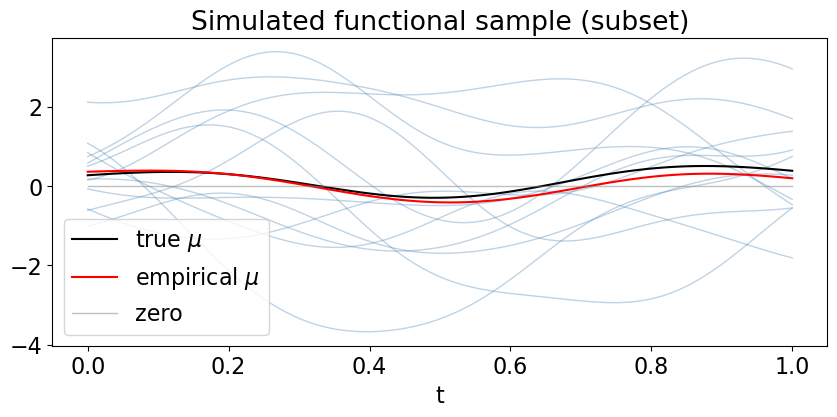

In [3]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for i in range(nsamples//4):
    ax.plot(grid, X[i], color='steelblue', alpha=0.35, lw=1.0)
ax.plot(grid, mu_true, color='black', lw=1.5, label='true $\\mu$')
ax.plot(grid, np.mean(X, axis=0), color='red', lw=1.5, label='empirical $\\mu$')
ax.plot(grid, np.zeros(grid.size), color='gray', alpha=0.5, lw=1.0, label='zero')
ax.set_title('Simulated functional sample (subset)')
ax.set_xlabel('t')
ax.legend()
plt.show()

## 3) Fit RK-BT model with Eryn RJMCMC

In [4]:
cfg = RKBTConfig(
    pi0=0.5,
    eta=None,
    eta_scaling_factor=0.25,
    lambda_p=None,
    nwalkers=64,
    ntemps=5,
    nsteps=500,
    nburn=500,
    nleaves_min=1,
    nleaves_max=5,
    seed=seed+1,
    likelihood_engine="auto"
)

K_hat = SampleCovEstimator().estimate(X)
fit = fit_rkbt(X, K_hat, grid, config=cfg, progress=True)
summary = fit.summary

print("Effective η:", round(fit.eta, 4))
print('Posterior P(H0|X):', round(summary.posterior_null_prob, 4))
print('Naive MCSE (iid approx):', round(summary.mcse_naive, 5))
print('Bayes factor B_10:', round(np.exp(summary.log_bf10), 4))
print('Posterior mean p:', round(summary.p_samples.mean(), 3))

100%|██████████| 500/500 [00:11<00:00, 44.49it/s]


Effective η: 0.3729
Posterior P(H0|X): 0.378
Naive MCSE (iid approx): 0.0015
Bayes factor B_10: 1.6457
Posterior mean p: 2.738


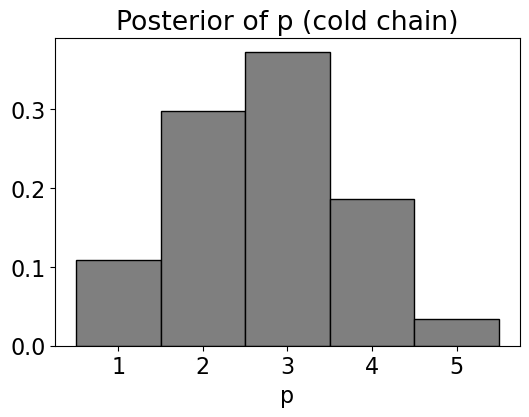

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

bins = np.arange(cfg.nleaves_min, cfg.nleaves_max + 2) - 0.5
ax.hist(summary.p_samples.reshape(-1), bins=bins, density=True, color='tab:gray', edgecolor='black')
ax.set_xticks(np.arange(cfg.nleaves_min, cfg.nleaves_max + 1))
ax.set_title('Posterior of p (cold chain)')
ax.set_xlabel('p')
plt.show()

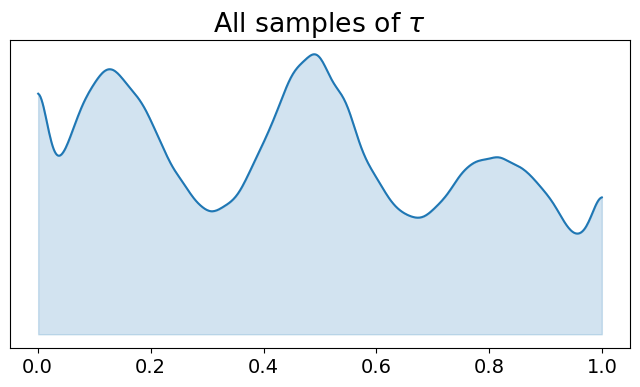

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
var = "$\\tau$"
ax.set_title(rf"All samples of {var}")
ax.set_yticks([])
ax.set_yticklabels([])
az.plot_dist(fit.tau_chain, fill_kwargs={"alpha": 0.2}, ax=ax)
plt.show()

## 4) Posterior mean function and simultaneous band

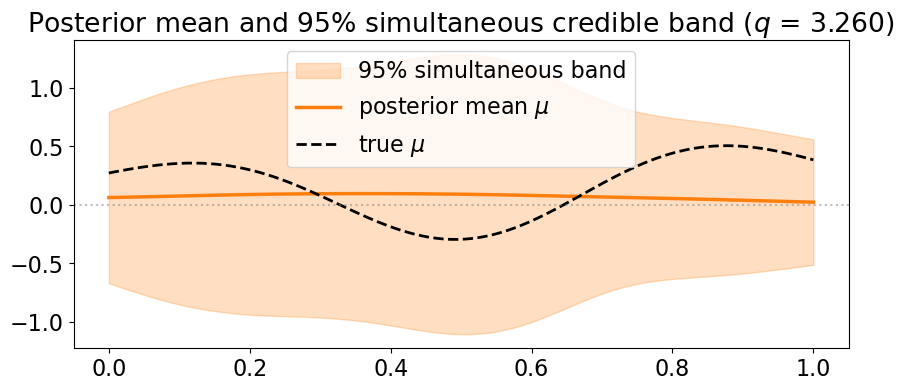

In [7]:
draws = fit.draw_posterior(ndraws=10000, rng=rng)
mu_draws = draws['mu_draws']
mu_pm = summary.posterior_mean_mu
lower_band, upper_band, c95 = simultaneous_credible_band(mu_draws, mu_pm, alpha=0.05)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.fill_between(grid, lower_band, upper_band, color='tab:orange', alpha=0.25, label='95% simultaneous band')
ax.plot(grid, mu_pm, color='tab:orange', lw=2.5, label='posterior mean $\\mu$')
ax.plot(grid, mu_true, color='black', lw=2, label='true $\\mu$', ls='--')
ax.axhline(0, ls=':', color='gray', alpha=0.5)
ax.legend()
ax.set_title(f'Posterior mean and 95% simultaneous credible band ($q$ = {c95:.3f})')
plt.show()

In [8]:
epsilon = 0.01
rope_epsilon = compute_rope(mu_draws, epsilon)
print("ROPE:", round(float(rope_epsilon), 5))

ROPE: 0.3727


## 6) Estimate unknown covariance

In [9]:
rel_fro = np.linalg.norm(K_hat - K_grid, ord='fro') / np.linalg.norm(K_grid, ord='fro')
max_abs = np.max(np.abs(K_hat - K_grid))
corr_vec = np.corrcoef(K_hat.ravel(), K_grid.ravel())[0, 1]

print('  relative Frobenius error ||Khat-K||_F / ||K||_F =', round(float(rel_fro), 6))
print('  max absolute entry error =', round(float(max_abs), 6))
print('  corr(vec(Khat), vec(Ktrue)) =', round(float(corr_vec), 6))

  relative Frobenius error ||Khat-K||_F / ||K||_F = 0.408527
  max absolute entry error = 0.807471
  corr(vec(Khat), vec(Ktrue)) = 0.881809


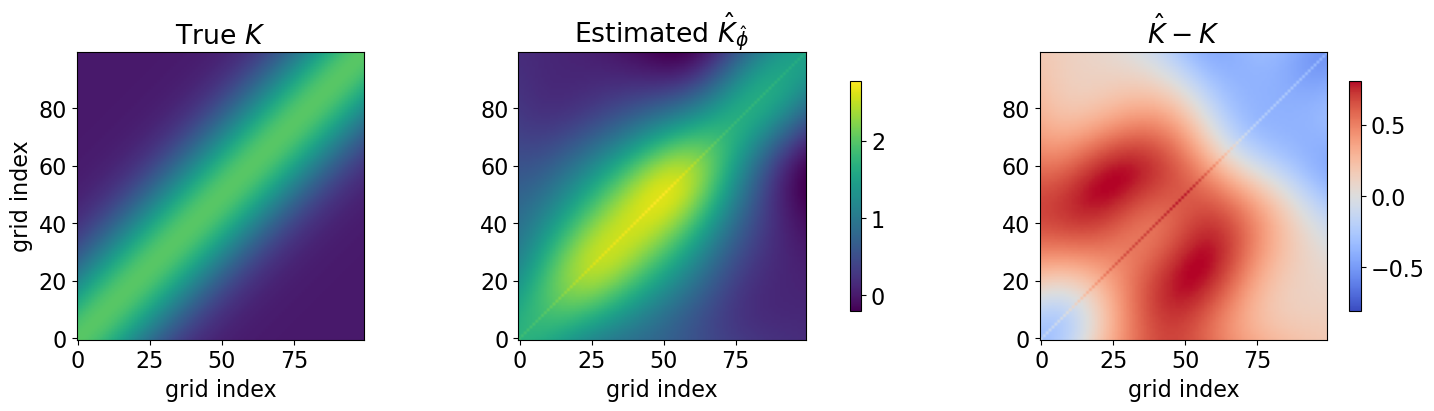

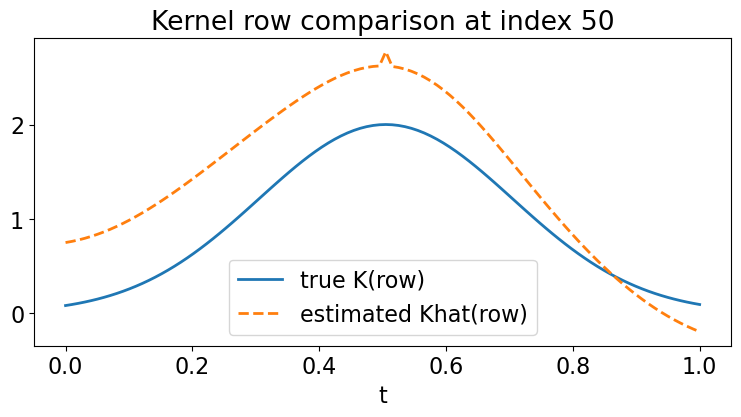

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

vmin = min(K_grid.min(), K_hat.min())
vmax = max(K_grid.max(), K_hat.max())

im0 = axs[0].imshow(K_grid, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axs[0].set_title('True $K$')
axs[0].set_xlabel('grid index')
axs[0].set_ylabel('grid index')

im1 = axs[1].imshow(K_hat, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)
axs[1].set_title(r'Estimated $\hat K_{\hat\phi}$')
axs[1].set_xlabel('grid index')

diff = K_hat - K_grid
lim = np.max(np.abs(diff))
im2 = axs[2].imshow(diff, origin='lower', cmap='coolwarm', vmin=-lim, vmax=lim)
axs[2].set_title(r'$\hat K - K$')
axs[2].set_xlabel('grid index')

fig.colorbar(im0, ax=axs[:2], shrink=0.8)
fig.colorbar(im2, ax=axs[2], shrink=0.8)
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(9, 4))
row_idx = 50
ax.plot(grid, K_grid[row_idx], label='true K(row)', lw=2)
ax.plot(grid, K_hat[row_idx], label='estimated Khat(row)', lw=2, ls='--')
ax.set_title(f'Kernel row comparison at index {row_idx}')
ax.set_xlabel('t')
ax.legend()
plt.show()

## 7) ROC Curves

In [11]:
nreps = 50
summaries_h0 = []
summaries_h1 = []
for n in range(nreps):
    cfg = RKBTConfig(
        pi0=0.5,
        eta=None,
        eta_scaling_factor=0.25,
        min_dist_tau=0,
        nwalkers=24,
        ntemps=1,
        nsteps=100,
        nburn=100,
        nleaves_min=1,
        nleaves_max=3,
        seed=seed + n,
        likelihood_engine="auto"
    )
    X_0 = rng.multivariate_normal(np.zeros(len(grid)), K_grid, size=nsamples)
    X_1 = rng.multivariate_normal(mu_true, K_grid, size=nsamples)

    fit_h0 = fit_rkbt(X_0, K_grid, grid, config=cfg, progress=False)
    fit_h1 = fit_rkbt(X_1, K_grid, grid, config=cfg, progress=False)
    summaries_h0.append(fit_h0.summary)
    summaries_h1.append(fit_h1.summary)

AUC: 0.944


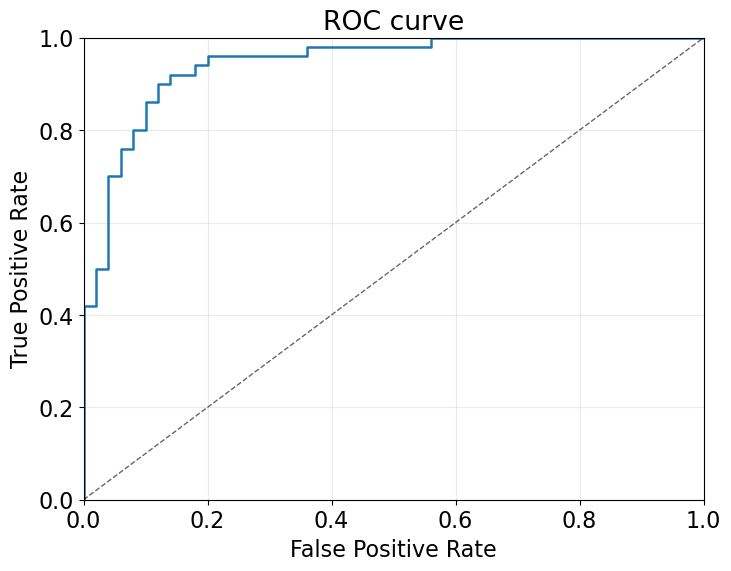

In [12]:
scores_h0 = np.array([s.log_bf10 for s in summaries_h0])
scores_h1 = np.array([s.log_bf10 for s in summaries_h1])
scores = np.concatenate([scores_h0, scores_h1])
labels = np.concatenate([np.zeros(len(scores_h0)), np.ones(len(scores_h1))])
fpr, tpr, _ = roc_curve(labels, scores)
auc = roc_auc_score(labels, scores)

print(f"AUC: {auc:.3f}")
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, lw=1.8)
ax.plot([0, 1], [0, 1], "k--", lw=1.0, alpha=0.6)
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC curve")
ax.grid(alpha=0.25)